# 09 · Modelos para actualizar la producción esperada

**Entrada:** única base analítica oficial. **Salidas:** predicciones, métricas y una simulación operacional dentro del notebook; ningún dataset adicional.

Pregunta central: **¿la producción reciente ayuda a ajustar las semanas siguientes y qué añaden siembras y clima?**

Se comparan modelos sencillos en tres periodos futuros respecto al entrenamiento. La comparación es retrospectiva y condicional a reportes observados: ausencia de reporte no significa cero. El target sigue siendo tallos reportados, no exportable certificado.

WebFlor tiene históricos físicos, pero no origen/vigencia certificados. No se entrena una falsa corrección WebFlor. Sí se implementa una corrección a una referencia conocida: la media de cuatro semanas. Los estimados del ingeniero quedan como benchmark descriptivo en 07, sin mezclarlos con esta validación.

No hay búsqueda masiva de parámetros ni selección automática del ganador. La documentación de [features rezagadas y evaluación temporal de scikit-learn](https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html) respalda separar pasado y futuro. El modelo de [HistGradientBoosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html) se ejecuta sin early stopping aleatorio.


## 1. Imports, datos y supuestos

Origen = lunes inicial de una semana; producción/clima sólo de semanas ya cerradas. Planos: disponibilidad supuesta posterior al cierre nominal y a AL1; tolerancia de cuatro semanas. Estas fechas no certifican publicación: más adelante se ensaya una demora adicional.


In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"
base = pd.read_parquet(SALIDA/"base_analitica.parquet")
KEY = ["finca","producto","color","variedad"]
SEM = KEY+["semana_inicio"]
assert not base.duplicated(SEM).any()
print("Fuente:",SALIDA/"base_analitica.parquet",base.shape)
print("Tallos conservados en la base:",int(base.tallos_reales.sum()))
pd.set_option("display.max_columns",25)


Fuente: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos_analiticos_proyecto\base_analitica.parquet (44053, 108)
Tallos conservados en la base: 327991200


## 2. Mismas features de 08, visibles y autocontenidas

Este bloque se repite intencionalmente para ejecutar 09 solo, sin scripts propios ni variables ocultas de otro notebook. Los lags se calculan sobre calendario regular. Los planos son estados, no nuevas plantas para sumar a través del tiempo. El potencial descriptivo calculado con todas las curvas NO se usa como predictor.


In [2]:
def construir_casos(base, retraso_semanas=0):
    """Una fila = serie/origen/horizonte. Ninguna X usa la producción objetivo."""
    key = ["finca","producto","color","variedad"]
    b = base.copy()
    b["semana_inicio"] = b.semana_inicio.astype("datetime64[ns]")
    calendario = pd.DataFrame({"origen":pd.date_range(b.semana_inicio.min(),
                        b.semana_inicio.max()+pd.Timedelta(weeks=1),freq="W-MON")})
    calendario["origen"] = calendario.origen.astype("datetime64[ns]")
    grid = b[key].drop_duplicates().merge(calendario,how="cross")
    grid = grid.merge(b[key+["semana_inicio","tallos_reales"]],
                      left_on=key+["origen"],right_on=key+["semana_inicio"],
                      how="left",validate="one_to_one").sort_values(key+["origen"])
    g = grid.groupby(key,sort=False).tallos_reales
    desfase = 1+retraso_semanas
    for lag in [1,2,3]:
        grid[f"produccion_lag{lag}"] = g.shift(lag+retraso_semanas)
    for v in [4,8]:
        grid[f"media_{v}"] = g.transform(lambda s:s.shift(desfase).rolling(v,min_periods=v).mean())
    grid["desv_4"] = g.transform(lambda s:s.shift(desfase).rolling(4,min_periods=4).std())
    grid["tendencia_4_8"] = grid.media_4-grid.media_8
    grid["cambio_reciente"] = grid.produccion_lag1-grid.produccion_lag2
    grid["observaciones_previas"] = g.transform(lambda s:s.notna().cumsum().shift(desfase,fill_value=0))
    grid = grid.drop(columns=["semana_inicio","tallos_reales"])

    # Planos: no llamar publicación a AL1. Supuesto prudente para el experimento:
    # disponibilidad posterior al cierre nominal Y a la fecha usada para calcular edad.
    p = b[key+["semana_inicio","fecha_referencia_edad_plano","plantas_plano","edad_media_plano"]].dropna(subset=["plantas_plano"]).copy()
    p["disponible_plano"] = pd.concat([p.semana_inicio+pd.Timedelta(days=7),
        pd.to_datetime(p.fecha_referencia_edad_plano)+pd.Timedelta(days=1)],axis=1).max(axis=1)
    p["disponible_plano"] = (p.disponible_plano+pd.Timedelta(weeks=retraso_semanas)).astype("datetime64[ns]")
    p = p.sort_values(["disponible_plano","semana_inicio"]).drop_duplicates(key+["disponible_plano"],keep="last")
    p = p.rename(columns={"semana_inicio":"semana_plano_usado","plantas_plano":"plantas_conocidas",
                          "edad_media_plano":"edad_plano_conocida"})
    grid = pd.merge_asof(grid.sort_values("origen"),p.drop(columns="fecha_referencia_edad_plano").sort_values("disponible_plano"),
        left_on="origen",right_on="disponible_plano",by=key,direction="backward",tolerance=pd.Timedelta(weeks=4))
    assert (grid.disponible_plano.isna() | grid.disponible_plano.le(grid.origen)).all()
    grid["antiguedad_plano"] = (grid.origen-grid.semana_plano_usado).dt.days/7
    grid["edad_proyectada_origen"] = grid.edad_plano_conocida+grid.antiguedad_plano

    # Cada finca/semana aparece en muchas variedades, pero clima sólo se cuenta una vez.
    cols = ["temperatura_semana","humedad_semana","radiacion_semana"]
    assert b.groupby(["finca","semana_inicio"])[cols].nunique().le(1).all().all()
    clima = b.groupby(["finca","semana_inicio"])[cols+["dias_clima"]].first().reset_index()
    clima.loc[clima.dias_clima.lt(5),cols] = np.nan  # una semana muy incompleta no representa su promedio
    clima = b[["finca"]].drop_duplicates().merge(calendario,how="cross").merge(
        clima.rename(columns={"semana_inicio":"origen"}),on=["finca","origen"],how="left",validate="one_to_one").sort_values(["finca","origen"])
    for col in cols:
        clima[col+"_lag1"] = clima.groupby("finca")[col].shift(desfase)
        clima[col+"_media4"] = clima.groupby("finca")[col].transform(lambda s:s.shift(desfase).rolling(4,min_periods=4).mean())
    clima = clima.drop(columns=cols+["dias_clima"])
    grid = grid.merge(clima,on=["finca","origen"],how="left",validate="many_to_one")

    etiquetas = b[key+["semana_inicio","tallos_reales"]].rename(columns={"semana_inicio":"semana_objetivo","tallos_reales":"y"})
    casos = []
    for h in range(1,6):
        d = grid.loc[grid.observaciones_previas.gt(0)].copy()
        d["horizonte"] = h
        d["semana_objetivo"] = d.origen+pd.Timedelta(weeks=h-1)
        d["ultima_semana_utilizada"] = d.origen-pd.Timedelta(weeks=desfase)
        d = d.merge(etiquetas,on=key+["semana_objetivo"],how="left",validate="many_to_one")
        d["fecha_estacional"] = d.semana_objetivo-pd.Timedelta(weeks=52)
        estacional = etiquetas.rename(columns={"semana_objetivo":"fecha_estacional","y":"produccion_52"})
        d = d.merge(estacional,on=key+["fecha_estacional"],how="left",validate="many_to_one")
        assert (d.fecha_estacional+pd.Timedelta(weeks=1+retraso_semanas)).le(d.origen).all()
        semana = d.semana_objetivo.dt.isocalendar().week.astype(float)
        d["semana_seno"] = np.sin(2*np.pi*semana/52)
        d["semana_coseno"] = np.cos(2*np.pi*semana/52)
        d["edad_proyectada_objetivo"] = d.edad_proyectada_origen+h-1
        casos.append(d)
    casos = pd.concat(casos,ignore_index=True)
    assert not casos.duplicated(key+["origen","horizonte"]).any()
    assert casos.ultima_semana_utilizada.lt(casos.origen).all()
    return casos

categoricas = ["producto","color","variedad"]
temporales = ["horizonte","semana_seno","semana_coseno"]
memoria = ["produccion_lag1","produccion_lag2","produccion_lag3","media_4","media_8",
           "desv_4","tendencia_4_8","cambio_reciente","produccion_52"]
agronomicas = ["plantas_conocidas","edad_proyectada_objetivo","antiguedad_plano"]
climaticas = [v+s for v in ["temperatura_semana","humedad_semana","radiacion_semana"] for s in ["_lag1","_media4"]]
X_columnas = categoricas+temporales+memoria+agronomicas+climaticas
assert "y" not in X_columnas

casos = construir_casos(base)
for col in temporales+memoria+agronomicas+climaticas:
    casos[col] = casos[col].astype(np.float32)
admisible = casos.y.notna() & casos.media_4.notna() & casos.observaciones_previas.ge(26)
datos_modelo = casos.loc[admisible].copy()
print("Casos con target:",int(casos.y.notna().sum()),"Admisibles:",len(datos_modelo))
display(datos_modelo[X_columnas].isna().mean().mul(100).round(1).to_frame("faltantes_pct"))


Casos con target: 211001 Admisibles: 143897


,faltantes_pct
producto,0.0
color,0.0
variedad,0.0
horizonte,0.0
semana_seno,0.0
semana_coseno,0.0
produccion_lag1,0.0
produccion_lag2,0.0
produccion_lag3,0.0
media_4,0.0


## 3. Experimento pequeño, antes de ver resultados

Tres cortes: julio de 2025, enero y mayo de 2026. Se entrena con objetivos cerrados al corte y se evalúan ocho orígenes semanales posteriores, H1–H5. El modelo queda fijo durante cada bloque pero recibe nueva producción conocida en cada origen. Entrenamientos posteriores pueden incorporar observaciones ya cerradas de bloques anteriores.

Modelos:
- Último valor; media 4; media 4 con reacción del 50% a la última desviación (regla fijada, no optimizada).
- Ridge con todas las features.
- Boosting sin producción reciente, con memoria, con memoria+siembra y completo: misma familia para comparar bloques de variables.
- Boosting del error respecto a media 4: `final = media4 + corrección`.

Los parámetros son fijos. Las categorías y medianas se ajustan **sólo en train**. No se convierte variedad en un número ordinal arbitrario: se usa one-hot, incluyendo categorías poco frecuentes. Predicciones negativas se limitan a cero por la unidad física; eso no imputa targets faltantes.

La referencia de 52 semanas se evaluará aparte porque no cubre todos los casos. No comparar su métrica directamente sin igualar población.


In [3]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8
columnas_modelo = {
    "Ridge_completo": X_columnas,
    "Boosting_sin_real_reciente": categoricas+temporales+agronomicas+climaticas,
    "Boosting_memoria": categoricas+temporales+memoria,
    "Boosting_memoria_siembra": categoricas+temporales+memoria+agronomicas,
    "Boosting_completo": X_columnas,
    "Boosting_ajuste_media4": X_columnas,
}

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)

def metricas(g):
    error = g.y-g.prediccion
    real = g.y.sum()
    return pd.Series({"n":len(g),"MAE":error.abs().mean(),"RMSE":np.sqrt(np.mean(error**2)),
        "WAPE":error.abs().sum()/real if real>0 else np.nan,"Bias":error.mean(),
        "dentro_8pct":(error.abs()<=.08*g.y).mean()})
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


## 4. Entrenar y predecir fuera de entrenamiento

Se muestra cobertura respecto a todos los casos con producción observada en cada bloque. El grano es caso de pronóstico: la misma producción puede ser objetivo desde varios orígenes; no sumar estas filas como inventario producido. Las claves de las predicciones deben ser únicas por modelo y caso.


In [4]:
resultados, cobertura, tiempos = [],[],[]
llave_caso = KEY+["origen","semana_objetivo","horizonte"]
for corte in CORTES:
    fin = corte+pd.Timedelta(weeks=SEMANAS_EVALUACION)
    train = datos_modelo.loc[(datos_modelo.semana_objetivo+pd.Timedelta(days=7)).le(corte)].copy()
    test = datos_modelo.loc[datos_modelo.origen.ge(corte)&datos_modelo.origen.lt(fin)].copy()
    universo = casos.loc[casos.y.notna()&casos.origen.ge(corte)&casos.origen.lt(fin)]
    assert (train.semana_objetivo+pd.Timedelta(days=7)).le(corte).all()
    assert test.origen.ge(corte).all()
    cobertura.append({"corte":corte,"train":len(train),"casos_observados":len(universo),
        "evaluados":len(test),"cobertura_casos":len(test)/len(universo),
        "cobertura_volumen_casos":test.y.sum()/universo.y.sum()})
    q = test[llave_caso+["y"]].copy()
    q["corte"] = corte
    referencias = {"Ultimo_valor":test.produccion_lag1,"Media4":test.media_4,
        "Media4_reaccion_50":test.media_4+.5*(test.produccion_lag1-test.media_4)}
    for nombre,pred in referencias.items():
        resultados.append(q.assign(modelo=nombre,prediccion=np.maximum(0,pred.to_numpy())))
    for nombre,columnas in columnas_modelo.items():
        inicio = time.perf_counter()
        modelo = crear_modelo(nombre,columnas)
        residuo = nombre=="Boosting_ajuste_media4"
        y_train = train.y-train.media_4 if residuo else train.y
        with threadpool_limits(limits=2):
            modelo.fit(train[columnas],y_train)
            pred = modelo.predict(test[columnas])
        if residuo:pred = pred+test.media_4.to_numpy()
        resultados.append(q.assign(modelo=nombre,prediccion=np.maximum(0,pred)))
        tiempos.append({"corte":corte,"modelo":nombre,"segundos":time.perf_counter()-inicio})
        print(corte.date(),nombre,"OK",round(tiempos[-1]["segundos"],1),"s",flush=True)
predicciones = pd.concat(resultados,ignore_index=True)
assert not predicciones.duplicated(["modelo"]+llave_caso).any()
assert np.isfinite(predicciones.prediccion).all()
assert predicciones.groupby("modelo").size().nunique()==1
display(pd.DataFrame(cobertura))
display(pd.DataFrame(tiempos))


2025-07-07 Ridge_completo OK 2.3 s


2025-07-07 Boosting_sin_real_reciente OK 26.6 s


2025-07-07 Boosting_memoria OK 23.7 s


2025-07-07 Boosting_memoria_siembra OK 25.3 s


2025-07-07 Boosting_completo OK 24.6 s


...

2026-05-04 Boosting_memoria_siembra OK 36.2 s


2026-05-04 Boosting_completo OK 29.5 s


2026-05-04 Boosting_ajuste_media4 OK 15.7 s


,corte,train,casos_observados,evaluados,cobertura_casos,cobertura_volumen_casos
0,2025-07-07,107786,6087,4750,0.780352,0.988327
1,2026-01-05,123537,7159,4767,0.665875,0.982964
2,2026-05-04,133560,5885,4591,0.780119,0.974663


,corte,modelo,segundos
0,2025-07-07,Ridge_completo,2.315411
1,2025-07-07,Boosting_sin_real_reciente,26.558604
2,2025-07-07,Boosting_memoria,23.712330
3,2025-07-07,Boosting_memoria_siembra,25.259446
4,2025-07-07,Boosting_completo,24.553338
5,2025-07-07,Boosting_ajuste_media4,24.726158
6,2026-01-05,Ridge_completo,2.535412
7,2026-01-05,Boosting_sin_real_reciente,31.542011
8,2026-01-05,Boosting_memoria,30.523715
9,2026-01-05,Boosting_memoria_siembra,30.986577


## 5. Métricas comparables, incluyendo composición y bajo volumen

El volumen global puede ocultar variedades difíciles. Se muestran resultados por horizonte, producto, color y variedad, además de la mediana del WAPE de las series. Los totales agregados se obtienen sumando exactamente los mismos casos pronosticados; no son el total de la finca si hay series excluidas.


,n,MAE,RMSE,WAPE,Bias,dentro_8pct
modelo,,,,,,
Ridge_completo,14108.0,2083.139494,3678.411577,0.196043,643.276537,0.209314
Boosting_memoria_siembra,14108.0,2130.837165,3948.506661,0.200532,810.010707,0.218741
Ultimo_valor,14108.0,2145.538560,3986.707734,0.201915,153.447689,0.228877
Boosting_completo,14108.0,2156.844257,3975.953014,0.202979,811.879544,0.213992
Media4_reaccion_50,14108.0,2171.124158,4000.829310,0.204323,156.150296,0.221435
Boosting_ajuste_media4,14108.0,2171.899732,4015.940351,0.204396,677.923019,0.212291
Boosting_memoria,14108.0,2184.041083,3987.916893,0.205539,507.455926,0.211866
Media4,14108.0,2379.669354,4365.105890,0.223949,158.852903,0.203076
Boosting_sin_real_reciente,14108.0,2662.647341,4710.708527,0.250580,1311.833464,0.176141


n          MAE         RMSE  \
modelo                     horizonte                                     
Boosting_ajuste_media4     1.0        2876.0  1745.201063  3338.387579   
                           2.0        2844.0  1985.186898  3691.949295   
                           3.0        2822.0  2231.643806  4094.900965   
                           4.0        2796.0  2373.467438  4279.977600   
                           5.0        2770.0  2542.302469  4582.789121   
Boosting_completo          1.0        2876.0  1755.833205  3199.060671   
                           2.0        2844.0  1982.364771  3648.382886   
                           3.0        2822.0  2232.757946  4124.738447   
                           4.0        2796.0  2333.796141  4266.370550   
                           5.0        2770.0  2496.389943  4529.445400   
Boosting_memoria           1.0        2876.0  1671.426455  3173.255849   
                           2.0        2844.0  1952.549725  3642.382425   
                           3.0        2822.0  2266.953243  4132.509902   
                           4.0        2796.0  2434.153746  4310.305809   
                           5.0        2770.0  2617.018691  4557.527691   
Boosting_memoria_siembra   1.0        2876.0  1750.801676  3232.944175   
                           2.0        2844.0  1966.310118  3657.070334   
                           3.0        2822.0  2202.809217  4110.927774   
                           4.0        2796.0  2305.770432  4238.762718   
                           5.0        2770.0  2444.439491  4412.434447   
Boosting_sin_real_reciente 1.0        2876.0  2560.372015  4506.555338   
                           2.0        2844.0  2625.302821  4614.786110   
                           3.0        2822.0  2730.895931  4859.129963   
                           4.0        2796.0  2668.549321  4743.115729   
                           5.0        2770.0  2731.691453  4827.696907   
Media4                     1.0        2876.0  1776.931676  3302.878271   
                           2.0        2844.0  2147.354342  3924.051059   
                           3.0        2822.0  2440.486003  4432.306729   
                           4.0        2796.0  2636.992221  4708.022979   
                           5.0        2770.0  2922.296841  5246.122404   
Media4_reaccion_50         1.0        2876.0  1504.722271  2771.666684   
                           2.0        2844.0  1901.252681  3489.331495   
                           3.0        2822.0  2227.507353  4034.701600   
                           4.0        2796.0  2462.185578  4391.210537   
                           5.0        2770.0  2788.873330  4999.910308   
Ridge_completo             1.0        2876.0  1763.064403  3030.810984   
                           2.0        2844.0  1914.610798  3375.344268   
                           3.0        2822.0  2099.581110  3686.589173   
                           4.0        2796.0  2209.332345  3882.027793   
                           5.0        2770.0  2444.366255  4315.264946   
Ultimo_valor               1.0        2876.0  1449.481572  2708.594061   
                           2.0        2844.0  1842.607243  3444.471993   
                           3.0        2822.0  2193.160879  3980.749886   
                           4.0        2796.0  2464.503577  4400.076390   
                           5.0        2770.0  2808.780505  5046.260385   

                                          WAPE         Bias  dentro_8pct  
modelo                     horizonte                                      
Boosting_ajuste_media4     1.0        0.168254   740.515561     0.258693  
                           2.0        0.187845   783.596398     0.224684  
                           3.0        0.208883   760.121239     0.211906  
                           4.0        0.222388   562.409811     0.180615  
                           5.0        0.234476   537.294970     0.183755  
Boosting_completo          1.0        0

n          MAE         RMSE  \
modelo                     corte                                          
Boosting_ajuste_media4     2025-07-07  4750.0  1794.678537  3148.703315   
                           2026-01-05  4767.0  2565.197794  4817.773710   
                           2026-05-04  4591.0  2153.809732  3898.936435   
Boosting_completo          2025-07-07  4750.0  1794.141841  3197.768333   
                           2026-01-05  4767.0  2454.980346  4578.283335   
                           2026-05-04  4591.0  2222.542742  4029.146278   
Boosting_memoria           2025-07-07  4750.0  1770.185014  2971.720652   
                           2026-01-05  4767.0  2532.080239  4723.881399   
                           2026-05-04  4591.0  2250.848680  4069.816682   
Boosting_memoria_siembra   2025-07-07  4750.0  1742.637760  3046.513816   
                           2026-01-05  4767.0  2418.308642  4530.040454   
                           2026-05-04  4591.0  2233.989125  4122.996430   
Boosting_sin_real_reciente 2025-07-07  4750.0  2179.892129  3812.348248   
                           2026-01-05  4767.0  2857.001397  5009.991971   
                           2026-05-04  4591.0  2960.317014  5204.993206   
Media4                     2025-07-07  4750.0  1961.487053  3464.730577   
                           2026-01-05  4767.0  2777.213027  5241.565168   
                           2026-05-04  4591.0  2399.550697  4195.885801   
Media4_reaccion_50         2025-07-07  4750.0  1791.884737  3228.543103   
                           2026-01-05  4767.0  2601.221995  4934.774434   
                           2026-05-04  4591.0  2116.911757  3621.857305   
Ridge_completo             2025-07-07  4750.0  1898.103139  3196.188973   
                           2026-01-05  4767.0  2355.001131  4362.214073   
                           2026-05-04  4591.0  1992.300520  3354.345343   
Ultimo_valor               2025-07-07  4750.0  1755.151579  3193.615769   
                           2026-01-05  4767.0  2654.673589  5010.887711   
                           2026-05-04  4591.0  2020.792638  3495.324043   

                                           WAPE         Bias  dentro_8pct  
modelo                     corte                                           
Boosting_ajuste_media4     2025-07-07  0.185985   233.760802     0.233474  
                           2026-01-05  0.230830   883.080022     0.185022  
                           2026-05-04  0.193507   924.446018     0.218689  
Boosting_completo          2025-07-07  0.185929   423.921478     0.233053  
                           2026-01-05  0.220912   799.238406     0.193623  
                           2026-05-04  0.199682  1226.399499     0.215421  
Boosting_memoria           2025-07-07  0.183446    -1.947575     0.223368  
                           2026-01-05  0.227850   752.507066     0.194252  
                           2026-05-04  0.202225   780.056195     0.218253  
Boosting_memoria_siembra   2025-07-07  0.180592   378.264373     0.233895  
                           2026-01-05  0.217612   817.660671     0.201175  
                           2026-05-04  0.200710  1248.766468     0.221303  
Boosting_sin_real_reciente 2025-07-07  0.225905   571.572220     0.192000  
                           2026-01-05  0.257088  1187.063236     0.173065  
                           2026-05-04  0.265967  2207.285565     0.162927  
Media4                     2025-07-07  0.203271    72.684316     0.222947  
                           2026-01-05  0.249908  1268.406545     0.180197  
                           2026-05-04  0.215585  -904.083587     0.206273  
Media4_reaccion_50         2025-07-07  0.185695    33.276263     0.244000  
                           2026-01-05  0.234071  1052.809629     0.190476  
                           2026-05-04  0.190192  -647.753730     0.230233  
Ridge_completo             2025-07-07  0.196703   740.047846     0.193895  
                           2026-01-05  0.211

n          MAE         RMSE  \
modelo                 producto                                           
Boosting_ajuste_media4 ACHILLEA         145.0   129.373384   169.074019   
                       AMAZON           120.0   697.058759   851.254576   
                       BARBATUS         577.0   496.409985   655.821579   
                       CARNATION       5505.0  1258.551897  1892.242207   
                       GREEN BALL       160.0  1786.574856  2200.801288   
...                                       ...          ...          ...   
Ultimo_valor           STAR             166.0  1929.090361  2526.625152   
                       STATICE          240.0   337.204167   527.309993   
                       TRACHELIUM       164.0  1444.829268  1774.523083   
                       VERONICA         360.0   803.322222  1081.670046   
                       VERONICA SPRAY   360.0   662.983333   873.557503   

                                           WAPE         Bias  dentro_8pct  
modelo                 producto                                            
Boosting_ajuste_media4 ACHILLEA        2.412751  -103.161581     0.013793  
                       AMAZON          0.293297  -173.670528     0.133333  
                       BARBATUS        0.336863  -243.884091     0.168111  
                       CARNATION       0.243844   157.899322     0.187466  
                       GREEN BALL      0.258250 -1109.258591     0.231250  
...                                         ...          ...          ...  
Ultimo_valor           STAR            0.165711   375.813253     0.331325  
                       STATICE         0.292493   -26.679167     0.187500  
                       TRACHELIUM      0.386222   624.341463     0.121951  
                       VERONICA        0.268595  -305.350000     0.194444  
                       VERONICA SPRAY  0.278411  -291.705556     0.227778  

[117 rows x 6 columns]

n          MAE  \
modelo                 producto  color                                  
Boosting_ajuste_media4 ACHILLEA  LIGHT PINK         60.0   110.955401   
                                 RED                25.0    90.661028   
                                 YELLOW             60.0   163.921515   
                       AMAZON    PURPLE            120.0   697.058759   
                       BARBATUS  DARK PINK           5.0   137.526903   
                                 HOT PINK           80.0   426.309594   
                                 LAVENDER          120.0   441.319445   
                                 LIGHT PINK        120.0   415.339940   
                                 PURPLE             15.0   205.959693   
                                 RED               120.0   477.739459   
                                 WHITE             117.0   755.717115   
                       CARNATION BICOLOR BURGUNDY  257.0   865.781537   
                                 BICOLOR PINK      200.0   979.883185   
                                 BICOLOR PURPLE    270.0   867.848934   
                                 BICOLOR RED       123.0  1080.237896   
                                 BICOLOR YELLOW    240.0  1343.583433   
                                 BURGUNDY          134.0  1056.408209   
                                 CREAM             240.0   899.959319   
                                 DARK PINK         145.0   692.752674   
                                 GOLD              159.0  1336.523957   
                                 GREEN             403.0   711.197743   
                                 HOT PINK          156.0  2304.076723   
                                 LAVENDER          240.0  1085.410148   
                                 LIGHT BROWN        50.0  1329.851946   
                                 LIGHT PINK        309.0  1526.228073   
                                 ORANGE            485.0  1397.407262   
                                 PEACH             360.0  1489.647310   
                                 PURPLE            248.0  1322.645252   
                                 RED               420.0  1502.818341   
                                 VINTAGE           285.0  1350.876893   

                                                          RMSE      WAPE  \
modelo                 producto  color                                     
Boosting_ajuste_media4 ACHILLEA  LIGHT PINK         141.245228  1.920751   
                                 RED                105.699581  3.649800   
                                 YELLOW             210.896917  2.666836   
                       AMAZON    PURPLE             851.254576  0.293297   
                       BARBATUS  DARK PINK          204.781131  0.196467   
                                 HOT PINK           527.899732  0.270587   
                                 LAVENDER           568.010850  0.287076   
                                 LIGHT PINK         520.347239  0.244848   
                                 PURPLE             220.655839  0.971508   
                                 RED                609.963706  0.316698   
                                 WHITE              965.561544  0.595373   
                       CARNATION BICOLOR BURGUNDY  1214.200335  0.214486   
                                 BICOLOR PINK      1242.067342  0.220267   
                                 BICOLOR PURPLE    1114.921807  0.234442   
                                 BICOLOR RED       1362.915179  0.224663   
                                 BICOLOR YELLOW    1806.653565  0.227611   
                                 BURGUNDY          1430.015053  0.224485   
                                 CREAM             1118.783701  0.212326   
                                 DARK PINK          900.965964  0.343737   
                                 GOLD              1685.209992  0.240856   
                                 GREEN        

,series,mediana_WAPE,p90_WAPE
modelo,,,
Boosting_ajuste_media4,172,0.263387,1.000000
Boosting_completo,172,0.250727,6.102095
Boosting_memoria,172,0.255483,6.667977
Boosting_memoria_siembra,172,0.246879,5.832214
Boosting_sin_real_reciente,172,0.308992,7.611722
Media4,172,0.267024,0.660420
Media4_reaccion_50,172,0.250610,0.667502
Ridge_completo,172,0.281228,6.862876
Ultimo_valor,172,0.252406,0.649097


n  \
modelo                     finca   producto      color          variedad                     
Ridge_completo             GAITANA MINICARNATION BICOLOR PURPLE JULIANA               10.0   
Boosting_sin_real_reciente GAITANA ACHILLEA      RED            SASSY SUMMER SANGRIA  25.0   
                                   MINICARNATION RED            SHELBY                22.0   
                                   SOLOMIO       BICOLOR YELLOW LALA SINT             16.0   
Boosting_completo          GAITANA MINICARNATION RED            SHELBY                22.0   
                                   ACHILLEA      RED            SASSY SUMMER SANGRIA  25.0   
Boosting_memoria_siembra   GAITANA MINICARNATION RED            SHELBY                22.0   
                                   ACHILLEA      RED            SASSY SUMMER SANGRIA  25.0   
Boosting_memoria           GAITANA MINICARNATION RED            SHELBY                22.0   
Boosting_completo          GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT             16.0   
Boosting_memoria_siembra   GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT             16.0   
Ridge_completo             GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT             16.0   
                                   MINICARNATION RED            SHELBY                22.0   
Boosting_memoria           GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT             16.0   
                                   ACHILLEA      RED            SASSY SUMMER SANGRIA  25.0   
                                   MINICARNATION BICOLOR PURPLE JULIANA               10.0   
Boosting_sin_real_reciente GAITANA MINICARNATION GREEN          RASCAL GREEN          37.0   
Boosting_memoria_siembra   GAITANA MINICARNATION BICOLOR PURPLE JULIANA               10.0   
Ridge_completo             GAITANA SOLOMIO       WHITE          CALMFLY               15.0   
Boosting_memoria           GAITANA MINICARNATION GREEN          RASCAL GREEN          37.0   

                                                                                              MAE  \
modelo                     finca   producto      color          variedad                            
Ridge_completo             GAITANA MINICARNATION BICOLOR PURPLE JULIANA               1193.060645   
Boosting_sin_real_reciente GAITANA ACHILLEA      RED            SASSY SUMMER SANGRIA  1212.240636   
                                   MINICARNATION RED            SHELBY                1300.976135   
                                   SOLOMIO       BICOLOR YELLOW LALA SINT             1538.469829   
Boosting_completo          GAITANA MINICARNATION RED            SHELBY                 949.423018   
                                   ACHILLEA      RED            SASSY SUMMER SANGRIA   854.969364   
Boosting_memoria_siembra   GAITANA MINICARNATION RED            SHELBY                 927.768935   
                                   ACHILLEA      RED            SASSY SUMMER SANGRIA   823.208629   
Boosting_memoria           GAITANA MINICARNATION RED            SHELBY                 772.467641   
Boosting_completo          GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT             1046.788045   
Boosting_memoria_siembra   GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT             1036.696081   
Ridge_completo             GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT             1028.890564   
                                   MINICARNATION RED            SHELBY                 651.458407   
Boosting_memoria           GAITANA SOLOMIO       BICOLOR YELLOW LALA SINT              887.876700   
                                   ACHILLEA      RED            SASSY SUMMER SANGRIA   586.763132   
                                   MINICARNATION BICOLOR PURPLE JULIANA                485.938425   
Boosting_sin_real_reciente GAITANA MINICARNATION GREEN          RASCAL GREEN           818.675395   
Boosting_memoria_siembra   GAITANA MINICARNATION BICOLOR PURPLE JULIANA                390.813432   


n          MAE         RMSE  \
modelo                     segmento                                          
Boosting_ajuste_media4     alto          13544.0  2252.521369  4097.491146   
                           bajo_o_nuevo    564.0   235.836866   488.496458   
Boosting_completo          alto          13544.0  2220.113183  4055.224917   
                           bajo_o_nuevo    564.0   637.492616   720.867299   
Boosting_memoria           alto          13544.0  2245.599092  4067.056689   
                           bajo_o_nuevo    564.0   705.775713   771.481573   
Boosting_memoria_siembra   alto          13544.0  2193.179685  4027.223247   
                           bajo_o_nuevo    564.0   633.732390   716.984050   
Boosting_sin_real_reciente alto          13544.0  2739.180714  4803.695055   
                           bajo_o_nuevo    564.0   824.760800   972.189952   
Media4                     alto          13544.0  2472.157524  4453.949081   
                           bajo_o_nuevo    564.0   158.641401   488.594236   
Media4_reaccion_50         alto          13544.0  2255.596980  4082.328949   
                           bajo_o_nuevo    564.0   142.578236   432.091792   
Ridge_completo             alto          13544.0  2152.925593  3752.374791   
                           bajo_o_nuevo    564.0   407.283261   576.541165   
Ultimo_valor               alto          13544.0  2229.281158  4068.056641   
                           bajo_o_nuevo    564.0   134.528369   398.288386   

                                             WAPE         Bias  dentro_8pct  
modelo                     segmento                                          
Boosting_ajuste_media4     alto          0.203747   706.794027     0.220097  
                           bajo_o_nuevo  0.759439   -15.390692     0.024823  
Boosting_completo          alto          0.200815   868.106278     0.222386  
                           bajo_o_nuevo  2.052847  -538.359618     0.012411  
Boosting_memoria           alto          0.203121   555.191194     0.220319  
                           bajo_o_nuevo  2.272731  -638.867602     0.008865  
Boosting_memoria_siembra   alto          0.198379   866.052670     0.227481  
                           bajo_o_nuevo  2.040738  -535.791329     0.008865  
Boosting_sin_real_reciente alto          0.247766  1393.291175     0.183181  
                           bajo_o_nuevo  2.655886  -644.307018     0.007092  
Media4                     alto          0.223613   164.742247     0.207324  
                           bajo_o_nuevo  0.510855    17.425089     0.101064  
Media4_reaccion_50         alto          0.204025   162.706623     0.225413  
                           bajo_o_nuevo  0.459129    -1.294548     0.125887  
Ridge_completo             alto          0.194738   679.947869     0.216627  
                           bajo_o_nuevo  1.311529  -237.355603     0.033688  
Ultimo_valor               alto          0.201645   160.670998     0.232058  
                           bajo_o_nuevo  0.433207   -20.014184     0.152482

,n,MAE,RMSE,WAPE,Bias,dentro_8pct
modelo,,,,,,
Boosting_ajuste_media4,120.0,122816.833346,161400.733082,0.098312,79701.149548,0.508333
Boosting_completo,120.0,126357.018265,161199.609941,0.101146,95449.971720,0.483333
Boosting_memoria,120.0,112998.019358,151140.142504,0.090452,59659.901666,0.541667
Boosting_memoria_siembra,120.0,124490.806586,161957.369765,0.099652,95230.258743,0.516667
Boosting_sin_real_reciente,120.0,163993.703652,200415.301365,0.131273,154227.887636,0.350000
Media4,120.0,113121.522917,153403.848046,0.090551,18675.806250,0.583333
Media4_reaccion_50,120.0,107345.803125,147588.811385,0.085928,18358.069792,0.591667
Ridge_completo,120.0,114559.583215,144775.468125,0.091702,75627.878162,0.525000
Ultimo_valor,120.0,119854.000000,160376.396302,0.095940,18040.333333,0.541667


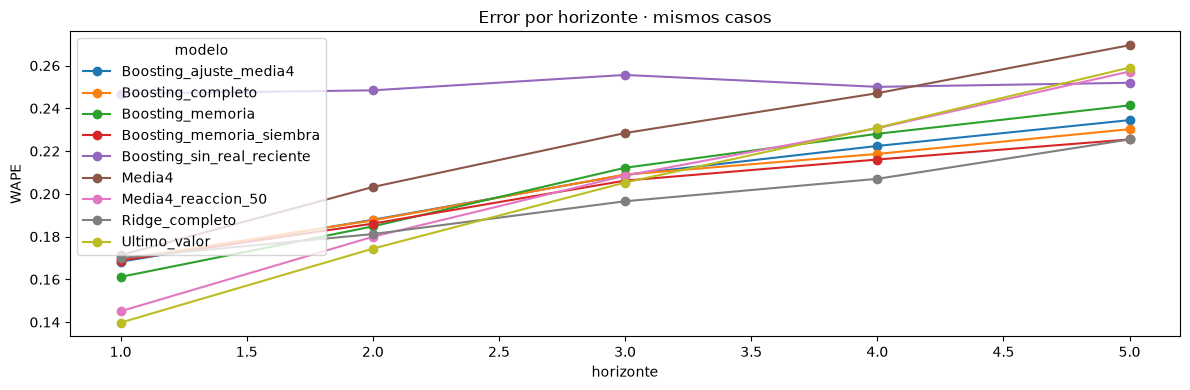

In [5]:
resumen = predicciones.groupby("modelo").apply(metricas).sort_values("WAPE")
por_horizonte = predicciones.groupby(["modelo","horizonte"]).apply(metricas)
por_corte = predicciones.groupby(["modelo","corte"]).apply(metricas)
por_producto = predicciones.groupby(["modelo","producto"]).apply(metricas)
por_color = predicciones.groupby(["modelo","producto","color"]).apply(metricas)
por_variedad = predicciones.groupby(["modelo"]+KEY).apply(metricas)
display(resumen)
display(por_horizonte)
display(por_corte)
display(por_producto)
display(por_color.head(30))
display(por_variedad.groupby("modelo").agg(
    series=("WAPE","size"),mediana_WAPE=("WAPE","median"),p90_WAPE=("WAPE",lambda s:s.quantile(.9))))
display(por_variedad.query("n>=10").sort_values("WAPE",ascending=False).head(20))
# El grupo de volumen se fija en train de cada corte, no con el volumen futuro.
segmentados = []
for corte,g in predicciones.groupby("corte"):
    historia = base.loc[(base.semana_inicio+pd.Timedelta(days=7)).le(corte)]
    volumen = historia.groupby(KEY).tallos_reales.mean().rename("volumen_historico").reset_index()
    umbral = volumen.volumen_historico.median()
    g = g.merge(volumen,on=KEY,how="left",validate="many_to_one")
    g["segmento"] = np.where(g.volumen_historico.ge(umbral),"alto","bajo_o_nuevo")
    segmentados.append(g)
display(pd.concat(segmentados).groupby(["modelo","segmento"]).apply(metricas))
# Coherencia por construcción: sumar variedades a color y producto, sin duplicarlas.
total_variedad = predicciones.groupby(["modelo","origen","horizonte"]).prediccion.sum()
nivel_color = predicciones.groupby(["modelo","origen","horizonte","producto","color"]).prediccion.sum()
pd.testing.assert_series_equal(total_variedad.sort_index(),
    nivel_color.groupby(["modelo","origen","horizonte"]).sum().sort_index(),check_exact=False)
agregadas = predicciones.groupby(["modelo","origen","horizonte"]).agg(
    y=("y","sum"),prediccion=("prediccion","sum")).reset_index()
display(agregadas.groupby("modelo").apply(metricas))
por_horizonte.WAPE.unstack("modelo").plot(figsize=(12,4),marker="o",title="Error por horizonte · mismos casos")
plt.ylabel("WAPE");plt.tight_layout();plt.show()


## 6. ¿Qué aporta cada bloque? ¿Qué pasa con una semana adicional de demora?

La comparación entre variantes de boosting mantiene los casos y parámetros. Una diferencia positiva en la tabla siguiente significa reducción de WAPE al añadir ese bloque; no causalidad.

La sensibilidad vuelve a construir y entrenar con una semana adicional de retraso. Compara en la intersección exacta de casos del último bloque. Una mejora de un escenario no demuestra la latencia real de las fuentes.


In [6]:
comparaciones = [
 ("memoria productiva","Boosting_sin_real_reciente","Boosting_completo"),
 ("siembras","Boosting_memoria","Boosting_memoria_siembra"),
 ("clima","Boosting_memoria_siembra","Boosting_completo"),
 ("corregir media4","Media4","Boosting_ajuste_media4"),
]
aporte = pd.DataFrame([{"bloque":bloque,"referencia":a,"comparado":z,
    "WAPE_referencia":resumen.loc[a,"WAPE"],"WAPE_comparado":resumen.loc[z,"WAPE"],
    "reduccion_puntos_WAPE":100*(resumen.loc[a,"WAPE"]-resumen.loc[z,"WAPE"])}
    for bloque,a,z in comparaciones])
display(aporte)
# Baseline estacional: sólo compararlo en la misma población que tiene ese dato.
est = predicciones.merge(casos[llave_caso+["produccion_52"]],on=llave_caso,how="left",validate="many_to_one")
est = est.loc[est.produccion_52.notna()].copy()
base52 = est.loc[est.modelo.eq("Media4")].copy()
base52["modelo"],base52["prediccion"] = "Estacional52",base52.produccion_52
display(pd.concat([est,base52]).groupby("modelo").apply(metricas))
print("Casos estacionales por modelo:",len(base52),"; no comparar directamente con la población principal.")
del est,base52

demora = construir_casos(base,retraso_semanas=1)
for col in temporales+memoria+agronomicas+climaticas:demora[col]=demora[col].astype(np.float32)
corte = CORTES[-1]
admitida = demora.y.notna()&demora.media_4.notna()&demora.observaciones_previas.ge(26)
tr = demora.loc[admitida&(demora.semana_objetivo+pd.Timedelta(days=14)).le(corte)]
te = demora.loc[admitida&demora.origen.ge(corte)&demora.origen.lt(corte+pd.Timedelta(weeks=SEMANAS_EVALUACION))]
referencia = predicciones.loc[predicciones.corte.eq(corte)&predicciones.modelo.isin(["Media4","Boosting_completo"])]
comunes = te[llave_caso].merge(referencia[llave_caso].drop_duplicates(),on=llave_caso,validate="one_to_one")
te = te.merge(comunes,on=llave_caso,validate="one_to_one")
md = crear_modelo("Boosting_completo",X_columnas)
with threadpool_limits(limits=2):
    md.fit(tr[X_columnas],tr.y)
    pred_demora = np.maximum(0,md.predict(te[X_columnas]))
sensibilidad = referencia.merge(comunes,on=llave_caso,validate="many_to_one").assign(escenario="cierre_supuesto")
qs = te[llave_caso+["y"]].copy()
sensibilidad = pd.concat([sensibilidad,
    qs.assign(modelo="Boosting_completo",prediccion=pred_demora,escenario="demora_1_semana"),
    qs.assign(modelo="Media4",prediccion=te.media_4.to_numpy(),escenario="demora_1_semana")],ignore_index=True)
display(sensibilidad.groupby(["escenario","modelo"]).apply(metricas))
del demora,tr,te,md


,bloque,referencia,comparado,WAPE_referencia,WAPE_comparado,reduccion_puntos_WAPE
0,memoria productiva,Boosting_sin_real_reciente,Boosting_completo,0.250580,0.202979,4.760079
1,siembras,Boosting_memoria,Boosting_memoria_siembra,0.205539,0.200532,0.500698
2,clima,Boosting_memoria_siembra,Boosting_completo,0.200532,0.202979,-0.244751
3,corregir media4,Media4,Boosting_ajuste_media4,0.223949,0.204396,1.955306


,n,MAE,RMSE,WAPE,Bias,dentro_8pct
modelo,,,,,,
Boosting_ajuste_media4,12196.0,2412.440202,4299.088167,0.201672,772.044632,0.227534
Boosting_completo,12196.0,2382.954438,4257.039070,0.199207,948.582712,0.227862
Boosting_memoria,12196.0,2398.411109,4265.913017,0.200499,624.873084,0.229747
Boosting_memoria_siembra,12196.0,2353.759022,4227.556765,0.196766,948.084476,0.232699
Boosting_sin_real_reciente,12196.0,2945.429736,5043.503163,0.246228,1502.178938,0.190800
Estacional52,12196.0,4693.217940,7453.838997,0.392337,2566.975730,0.095605
Media4,12196.0,2652.792247,4674.229144,0.221764,174.385721,0.213923
Media4_reaccion_50,12196.0,2417.257472,4282.749093,0.202074,173.904569,0.232617
Ridge_completo,12196.0,2286.817623,3931.191955,0.191170,775.408914,0.224418


Casos estacionales por modelo: 12196 ; no comparar directamente con la población principal.


n          MAE         RMSE      WAPE  \
escenario       modelo                                                          
cierre_supuesto Boosting_completo  4533.0  2244.096082  4054.000946  0.199168   
                Media4             4533.0  2425.881370  4221.555346  0.215302   
demora_1_semana Boosting_completo  4533.0  2601.928656  4775.225508  0.230927   
                Media4             4533.0  2816.790702  5005.976518  0.249996   

                                          Bias  dentro_8pct  
escenario       modelo                                       
cierre_supuesto Boosting_completo  1244.784835     0.218178  
                Media4             -918.176428     0.208251  
demora_1_semana Boosting_completo  1472.963445     0.189499  
                Media4            -1261.304710     0.187293

## 7. Ver cómo se actualiza una misma semana objetivo

Ejemplo de la corrección a media4 desde varios orígenes: la nueva producción modifica las features y puede subir o bajar el pronóstico. Acercarse al objetivo no garantiza menor error en cada caso. La línea real se muestra sólo para evaluar retrospectivamente.


,producto,color,variedad,origen,semana_objetivo,horizonte,prediccion,y
41348,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2025-08-04,2025-08-25,4.0,63.905771,60
40608,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2025-08-11,2025-08-25,3.0,31.405771,60
39691,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2025-08-18,2025-08-25,2.0,360.698377,60
38872,ACHILLEA,LIGHT PINK,SASSY SUMMER TAFFY,2025-08-25,2025-08-25,1.0,341.698377,60


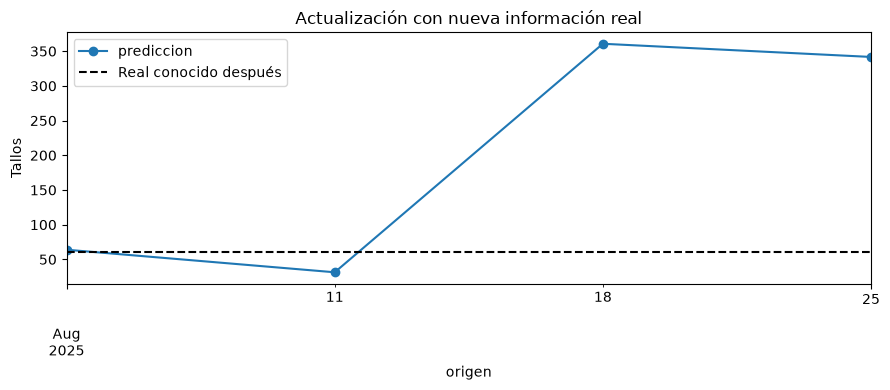

In [7]:
ejemplos = predicciones.loc[predicciones.modelo.eq("Boosting_ajuste_media4")].copy()
soporte = ejemplos.groupby(KEY+["semana_objetivo"]).agg(origenes=("origen","nunique"),real=("y","first")).reset_index()
elegida = soporte.loc[soporte.origenes.ge(4)].sort_values(KEY+["semana_objetivo"]).iloc[0]
mascara = pd.Series(True,index=ejemplos.index)
for col in KEY+["semana_objetivo"]:mascara &= ejemplos[col].eq(elegida[col])
trayectoria = ejemplos.loc[mascara].sort_values("origen")
display(trayectoria[["producto","color","variedad","origen","semana_objetivo","horizonte","prediccion","y"]])
ax = trayectoria.plot(x="origen",y="prediccion",marker="o",figsize=(9,4),title="Actualización con nueva información real")
ax.axhline(trayectoria.y.iloc[0],color="black",linestyle="--",label="Real conocido después")
ax.legend();plt.ylabel("Tallos");plt.tight_layout();plt.show()


## 8. Simulación de salida operacional desde el último origen local

Se usa el modelo de ajuste a media4 como **candidato ilustrativo fijado**, no como ganador elegido con el test. Se ajusta con objetivos cerrados al último origen local y se muestra H1–H5 para series con cuatro semanas recientes y 26 observaciones históricas. La base es la media móvil, no WebFlor.

Esta simulación NO fue emitida históricamente en ese origen y NO es un pronóstico actualizado a hoy si los archivos están atrasados. Series nuevas o sin el histórico reciente exigido quedan fuera; no se interpreta su ausencia como producción cero. En esta simulación no se exige conocer el target futuro; ese requisito sólo se aplica para puntuar casos históricos. No hay exportación automática ni decisión comercial.


In [8]:
origen_local = casos.origen.max()
train_final = datos_modelo.loc[(datos_modelo.semana_objetivo+pd.Timedelta(days=7)).le(origen_local)]
futuro = casos.loc[casos.origen.eq(origen_local)&casos.media_4.notna()&casos.observaciones_previas.ge(26)].copy()
mf = crear_modelo("Boosting_ajuste_media4",X_columnas)
with threadpool_limits(limits=2):
    mf.fit(train_final[X_columnas],train_final.y-train_final.media_4)
    ajuste = mf.predict(futuro[X_columnas])
salida_operativa = futuro[KEY+["origen","semana_objetivo","horizonte"]].copy()
salida_operativa["estimado_base"] = futuro.media_4.to_numpy()
salida_operativa["estimado_final"] = np.maximum(0,salida_operativa.estimado_base+ajuste)
salida_operativa["ajuste_modelo"] = salida_operativa.estimado_final-salida_operativa.estimado_base
salida_operativa["unidad"] = "tallos reportados"
salida_operativa["modelo"] = "Boosting_ajuste_media4_experimental"
salida_operativa["tipo"] = "simulacion_desde_ultimo_origen_local"
print("Fecha real de esta ejecución:",pd.Timestamp.now())
print("Origen simulado:",origen_local,"Series cubiertas:",futuro[KEY].drop_duplicates().shape[0])
display(salida_operativa.head(20))
display(salida_operativa.groupby(["producto","color","semana_objetivo"]).estimado_final.sum().unstack("semana_objetivo").head(20))
print("Ningún dataset adicional exportado. Los resultados completos están en memoria y las salidas del notebook.")


Fecha real de esta ejecución: 2026-09-24 17:19:03.322786
Origen simulado: 2026-09-07 00:00:00 Series cubiertas: 118


,finca,producto,color,variedad,origen,semana_objetivo,horizonte,estimado_base,estimado_final,ajuste_modelo,unidad,modelo,tipo
123578,GAITANA,MINICARNATION,LAVENDER,MOCHA SWEET,2026-09-07,2026-09-07,1.0,9979.25,8852.284707,-1126.965293,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123579,GAITANA,MINICARNATION,LAVENDER,NENUFAR,2026-09-07,2026-09-07,1.0,43936.25,46309.148884,2372.898884,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123581,GAITANA,MINICARNATION,BURGUNDY,CHATEAU,2026-09-07,2026-09-07,1.0,29728.00,26160.469259,-3567.530741,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123583,GAITANA,MINICARNATION,BICOLOR YELLOW,LAVA,2026-09-07,2026-09-07,1.0,24709.50,24022.293102,-687.206898,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123594,GAITANA,CARNATION,CREAM,HALO,2026-09-07,2026-09-07,1.0,3279.25,3613.606977,334.356977,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123596,GAITANA,CARNATION,BICOLOR PINK,ANTIGUA,2026-09-07,2026-09-07,1.0,4110.25,3950.342701,-159.907299,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123608,GAITANA,MINICARNATION,YELLOW,CAESAR,2026-09-07,2026-09-07,1.0,63935.25,66580.502361,2645.252361,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123616,GAITANA,CARNATION,PURPLE,METALICA,2026-09-07,2026-09-07,1.0,4828.00,5043.232635,215.232635,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123618,GAITANA,CARNATION,CREAM,POLIMNIA,2026-09-07,2026-09-07,1.0,2942.25,3439.391486,497.141486,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local
123619,GAITANA,SOLOMIO,BICOLOR YELLOW,LALA BONITA,2026-09-07,2026-09-07,1.0,21637.50,22837.576140,1200.076140,tallos reportados,Boosting_ajuste_media4_experimental,simulacion_desde_ultimo_origen_local


semana_objetivo               2026-09-07    2026-09-14    2026-09-21  \
producto  color                                                        
AMAZON    PURPLE             2816.332036   2816.332036   2816.332036   
BARBATUS  HOT PINK           2378.645796   2378.645796   2378.645796   
          LAVENDER           2363.645796   2363.645796   2363.645796   
          LIGHT PINK         1998.832036   1998.832036   1998.832036   
          RED                1913.645796   1913.645796   1913.645796   
          WHITE              1232.449499   1232.449499   1232.449499   
CARNATION BICOLOR BURGUNDY  10183.147385  10183.147385  10183.147385   
          BICOLOR PINK       7700.531532   7632.879377   7632.879377   
          BICOLOR PURPLE     7795.036254   7667.403425   7604.825376   
          BICOLOR RED        4010.533502   4010.533502   4010.533502   
          BICOLOR YELLOW    15037.335521  14968.802708  14796.474075   
          BURGUNDY           5759.346203   5759.346203   5759.346203   
          CREAM              7052.998463   7024.175409   6896.542580   
          DARK PINK          2702.033502   2702.033502   2702.033502   
          GOLD               8570.820079   8570.820079   8570.820079   
          GREEN              8890.025517   8890.025517   8890.025517   
          HOT PINK          13481.103113  13378.977444  13245.831056   
          LAVENDER           9263.135345   9109.211769   8978.113783   
          LIGHT BROWN        4045.377223   4045.377223   3836.700062   
          LIGHT PINK        14022.740081  13764.009267  13701.431218   

semana_objetivo               2026-09-28    2026-10-05  
producto  color                                         
AMAZON    PURPLE             2852.068500   2852.068500  
BARBATUS  HOT PINK           2414.382261   2414.382261  
          LAVENDER           2399.382261   2399.382261  
          LIGHT PINK         2034.568500   2034.568500  
          RED                1949.382261   1949.382261  
          WHITE              1268.185963   1268.185963  
CARNATION BICOLOR BURGUNDY  10064.940442   9937.307613  
          BICOLOR PINK       7668.615841   7668.615841  
          BICOLOR PURPLE     7611.236792   7611.236792  
          BICOLOR RED        4046.269966   4046.269966  
          BICOLOR YELLOW    14820.732977  14820.732977  
          BURGUNDY           5795.082667   5730.523148  
          CREAM              6869.700995   6840.375947  
          DARK PINK          2737.769966   2673.210447  
          GOLD               8606.556544   8606.556544  
          GREEN              8961.498446   8961.498446  
          HOT PINK          13183.253007  13201.100494  
          LAVENDER           8799.843263   8732.191108  
          LIGHT BROWN        3836.700062   3769.047907  
          LIGHT PINK        13604.454014  13604.454014

Ningún dataset adicional exportado. Los resultados completos están en memoria y las salidas del notebook.


## 9. Conclusiones calculadas y límites

Las conclusiones siguientes se generan con los resultados de esta ejecución. No convertir un experimento retrospectivo en una aprobación operativa. El siguiente paso es revisar estabilidad por variedad/color, fechas de publicación y periodos nuevos antes de ajustar parámetros o elegir un modelo final.


In [9]:
print("HECHOS: se entrenaron Ridge y variantes de boosting; baselines y modelos comparten casos.")
for r in aporte.itertuples():
    verbo = "reduce" if r.reduccion_puntos_WAPE>0 else "no reduce"
    print(f"{r.bloque}: {verbo} el WAPE; diferencia = {r.reduccion_puntos_WAPE:.2f} puntos.")
print("Mejor WAPE observado en este experimento:",resumen.index[0],round(100*resumen.WAPE.iloc[0],2),"%")
print("Esto no selecciona un ganador operativo ni certifica precisión exportable.")
print("PENDIENTES: publicación real, unidades, ausencias/cero, variedades nuevas y vigencia WebFlor.")
print("DECISION: conservar producción reciente como hipótesis comprobable; evaluar aporte por bloque y periodo.")
print("El modelo híbrido con curvas requiere estimarlas sólo con ediciones previas al origen; el proxy retrospectivo no se usó.")


HECHOS: se entrenaron Ridge y variantes de boosting; baselines y modelos comparten casos.
memoria productiva: reduce el WAPE; diferencia = 4.76 puntos.
siembras: reduce el WAPE; diferencia = 0.50 puntos.
clima: no reduce el WAPE; diferencia = -0.24 puntos.
corregir media4: reduce el WAPE; diferencia = 1.96 puntos.
Mejor WAPE observado en este experimento: Ridge_completo 19.6 %
Esto no selecciona un ganador operativo ni certifica precisión exportable.
PENDIENTES: publicación real, unidades, ausencias/cero, variedades nuevas y vigencia WebFlor.
DECISION: conservar producción reciente como hipótesis comprobable; evaluar aporte por bloque y periodo.
El modelo híbrido con curvas requiere estimarlas sólo con ediciones previas al origen; el proxy retrospectivo no se usó.


## 10. Lectura de los resultados y siguiente decisión

Los valores siguientes corresponden a la ejecución guardada; al cambiar los datos, consultar de nuevo las tablas calculadas arriba.

### HECHOS CONFIRMADOS Y EVIDENCIA

- **La memoria productiva aporta señal:** boosting comparable pasa de 25,06% a 20,30% WAPE al añadir producción reciente. Las features estaban rezagadas y el entrenamiento sólo usó objetivos cerrados.
- **La complejidad no gana siempre:** el último valor logra 13,97% WAPE en H1 y 17,44% en H2, frente a 17,00% y 18,12% de Ridge. En H5, Ridge mejora: 22,54% frente a 25,91%.
- **El menor error global no basta:** Ridge tiene 19,60% WAPE global, pero 131,15% en el segmento bajo/nuevo frente a 43,32% del último valor. Su mediana por serie es 28,12%, peor que 25,24% del último valor. Hay problemas de escala y composición pendientes.
- **Siembras aporta una mejora pequeña en esta especificación:** aproximadamente 0,50 puntos de WAPE sobre memoria. El bloque climático ensayado empeora el conjunto en 0,24 puntos; no mejora en todos los cortes.
- **Disponibilidad importa:** una semana adicional de demora eleva WAPE del boosting de 19,92% a 23,09% sobre 4.533 casos comunes del último bloque.
- Los nueve métodos principales comparten 14.108 casos de 172 series. La cobertura por casos es 66,59–78,04% según bloque. No son todas las variedades ni todas las semanas posibles de la finca.

### INFERENCIAS E HIPÓTESIS AGRONÓMICAS

La producción reciente parece resumir condiciones del cultivo que no capturan completamente las otras fuentes. Puede orientar actualizaciones, pero no demuestra una relación causal. Que este bloque climático no mejore no prueba ausencia de efecto agronómico: importan cobertura, unidades, rezagos, heterogeneidad y confusión con estacionalidad.

### DECISIONES DE MODELADO

1. Mantener último valor y media4 como referencias obligatorias, y la corrección a media4 como demostración de actualización progresiva.
2. No aprobar Ridge sólo por el WAPE global ni exportar esta simulación como recomendación comercial.
3. Revisar escala, sesgo y soporte de variedades pequeñas antes de añadir algoritmos. Comparar en un periodo nuevo, sin optimizar sobre los bloques ya inspeccionados.
4. Mantener enfoque global como candidato para compartir información, pero contrastarlo por producto/color y volumen. Los resultados no justifican un modelo individual para cada variedad.
5. No incorporar el potencial de curvas completas como predictor histórico. El enfoque híbrido requiere reconstruir curvas usando exclusivamente entregas disponibles antes de cada origen.
6. Mantener separado el benchmark del ingeniero y la corrección WebFlor: ninguno tiene aquí una fecha de disponibilidad histórica certificada.

### PENDIENTES POR VALIDAR

Publicación de fuentes; producción reportada frente a exportable; ausencias frente a cero; manejo de variedades nuevas; vigencia y origen WebFlor; representatividad de curvas y clima. Los periodos ya analizados son desarrollo retrospectivo, no test prospectivo intacto.

**Conclusión:** ya funciona un recorrido simple y reproducible desde la base hasta predicciones actualizadas, métricas y una tabla operacional ilustrativa. Todavía no hay un modelo aprobado que garantice composición correcta por color/variedad ni una corrección WebFlor validada.